In [1]:
!pip install datasets transformers wandb evaluate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from datasets import load_dataset
import wandb
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import notebook_login

# Step 0: Login to WandB and Hugging Face
# You will need your API keys for this
wandb.init(project="STL10-Classification")
notebook_login() # To push model to Hugging Face

# Step 1: Load Data from HuggingFace
dataset = load_dataset("Chiranjeev007/STL-10_Subset")
train_ds = dataset['train']
val_ds = dataset['validation']
test_ds = dataset['test']

# Step 2: Custom Dataloader & Transformations
# ResNet-18 expects 224x224 images normalized to ImageNet stats
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def transform_fn(examples):
    # Return only the transformed pixel_values and the labels
    pixel_values = [data_transforms(image.convert("RGB")) for image in examples["image"]]
    labels = examples["label"]
    return {"pixel_values": pixel_values, "label": labels}

train_ds.set_transform(transform_fn)
val_ds.set_transform(transform_fn)
test_ds.set_transform(transform_fn)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32) # Corrected: Changed to test_ds

# Step 3: Pretrained ResNet-18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10) # 10 classes for STL-10
model = model.to(device)

# Step 4: Training & WandB Logging
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in train_loader:
            inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # Validation logic
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in val_loader:
                inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        wandb.log({
            "epoch": epoch,
            "train_loss": running_loss/len(train_loader),
            "train_acc": 100.*correct/total,
            "val_loss": val_loss/len(val_loader),
            "val_acc": 100.*val_correct/val_total
        })
        print(f"Epoch {epoch}: Val Acc {100.*val_correct/val_total:.2f}%")

train_model()

# Step 5: Push Best Model to Hugging Face
# In a real scenario, save and upload your .pth file or use the Trainer API
torch.save(model.state_dict(), "resnet18_stl10.pth")
# Use huggingface_hub to upload manually or via CLI

# Step 6-9: Evaluation & Visualization
model.eval()
all_preds = []
all_labels = []
images_to_log = []

class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)
        # The 'image' key is no longer directly available in the batch as it's not returned by transform_fn
        # raw_images = batch["image"]
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Step 7: Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(probs=None,
            y_true=all_labels, preds=all_preds, class_names=class_names)})

# Step 8: Class-wise Accuracy Bar Plot
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
class_accs = {k: v['precision'] for k, v in report.items() if k in class_names}
data = [[label, acc] for label, acc in class_accs.items()]
table = wandb.Table(data=data, columns=["label", "accuracy"])
wandb.log({"class_wise_accuracy": wandb.plot.bar(table, "label", "accuracy", title="Class-wise Accuracy")})

# Step 9: 20 Samples (10 correct, 10 incorrect)
# Iterate through and find indices to log to wandb.Image()
# ... logic to find 10 matches and 10 mismatches ...
# wandb.log({"test_samples": [wandb.Image(img, caption=f"Pred: {p}, Actual: {a}") for ...]})

wandb.finish()

epoch,▁▃▅▆█
train_acc,▁▄▆▇█
train_loss,█▅▃▂▁
val_acc,▁█▆▇▇
val_loss,█▁▁▄▆
epoch,4
train_acc,93.9
train_loss,0.18685
val_acc,74.6
val_loss,0.9459


/tmp/ipython-input-2083922810.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)
/tmp/ipython-input-2083922810.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)


Epoch 0: Val Acc 66.00%
Epoch 1: Val Acc 71.00%
Epoch 2: Val Acc 71.60%
Epoch 3: Val Acc 77.40%
Epoch 4: Val Acc 81.60%


/tmp/ipython-input-2083922810.py:119: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)


epoch,▁▃▅▆█
train_acc,▁▄▇██
train_loss,█▅▂▁▁
val_acc,▁▃▄▆█
val_loss,█▇▇▅▁
epoch,4
train_acc,91.9
train_loss,0.2364
val_acc,81.6
val_loss,0.64191


In [7]:
from huggingface_hub import HfApi

api = HfApi()


repo_id = "frostbyte012/resnet18-stl10-model"


api.create_repo(repo_id=repo_id, exist_ok=True)


api.upload_file(
    path_or_fileobj="resnet18_stl10.pth",
    path_in_repo="resnet18_stl10.pth",
    repo_id=repo_id,
    repo_type="model",
)

print(f"Model 'resnet18_stl10.pth' successfully uploaded to Hugging Face at: https://huggingface.co/{repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  resnet18_stl10.pth          :  56%|#####6    | 25.1MB / 44.8MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Model 'resnet18_stl10.pth' successfully uploaded to Hugging Face at: https://huggingface.co/frostbyte012/resnet18-stl10-model


In [8]:
from huggingface_hub import hf_hub_download

repo_id = 'frostbyte012/resnet18-stl10-model'
filename = 'resnet18_stl10.pth'

model_path = hf_hub_download(repo_id=repo_id, filename=filename)

print(f"Model downloaded to: {model_path}")

resnet18_stl10.pth:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

Model downloaded to: /root/.cache/huggingface/hub/models--frostbyte012--resnet18-stl10-model/snapshots/423e114d309a0337e113285ea4c37db6adee78ef/resnet18_stl10.pth


In [9]:
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

# Load the state dictionary
model.load_state_dict(torch.load(model_path))
model = model.to(device)

print("Model loaded and moved to device.")

Model loaded and moved to device.


In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions and true labels collected from the test set.")

/tmp/ipython-input-1771041706.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs, labels = batch["pixel_values"].to(device), torch.tensor(batch["label"]).to(device)


Predictions and true labels collected from the test set.


In [11]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch["pixel_values"].to(device), batch["label"].to(device) # Corrected line
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions and true labels collected from the test set.")

Predictions and true labels collected from the test set.


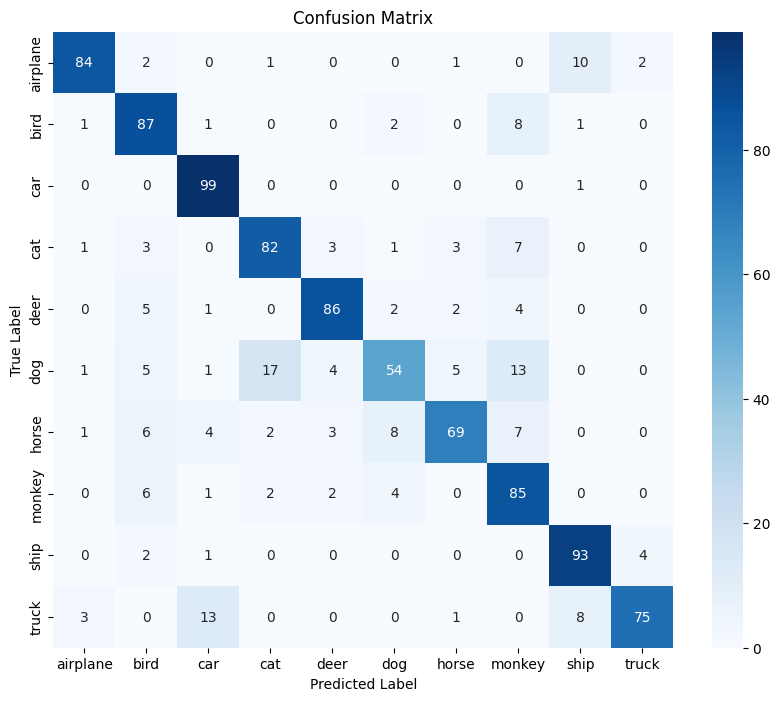

Confusion matrix generated and displayed.


In [12]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix generated and displayed.")

**Reasoning**:
With the confusion matrix displayed, the next step is to generate and display the class-wise accuracy report to further evaluate the model's performance on individual classes. The `report` variable from `classification_report` already contains this information.



In [13]:
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
class_accs = {k: v['precision'] for k, v in report.items() if k in class_names}

print("Class-wise Accuracy Report:")
for class_name, accuracy in class_accs.items():
    print(f"  {class_name}: {accuracy:.4f}")

print("\nClassification Report Summary:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Class-wise Accuracy Report:
  airplane: 0.9231
  bird: 0.7500
  car: 0.8182
  cat: 0.7885
  deer: 0.8776
  dog: 0.7606
  horse: 0.8519
  monkey: 0.6855
  ship: 0.8230
  truck: 0.9259

Classification Report Summary:
              precision    recall  f1-score   support

    airplane       0.92      0.84      0.88       100
        bird       0.75      0.87      0.81       100
         car       0.82      0.99      0.90       100
         cat       0.79      0.82      0.80       100
        deer       0.88      0.86      0.87       100
         dog       0.76      0.54      0.63       100
       horse       0.85      0.69      0.76       100
      monkey       0.69      0.85      0.76       100
        ship       0.82      0.93      0.87       100
       truck       0.93      0.75      0.83       100

    accuracy                           0.81      1000
   macro avg       0.82      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000



In [14]:
wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=all_labels,
        preds=all_preds,
        class_names=class_names
    )
})

data = [[label, acc] for label, acc in class_accs.items()]
table = wandb.Table(data=data, columns=["label", "accuracy"])
wandb.log({
    "class_wise_accuracy": wandb.plot.bar(
        table,
        "label",
        "accuracy",
        title="Class-wise Accuracy on Test Set"
    )
})

print("Confusion matrix and class-wise accuracy logged to Weights & Biases.")

Error: You must call wandb.init() before wandb.log()

**Reasoning**:
The previous attempt to log to Weights & Biases failed because the `wandb.init()` session had already finished. I need to re-initialize `wandb` to create a new run before logging the evaluation results.



In [15]:
import wandb

wandb.init(project="STL10-Classification", job_type="evaluation")

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=all_labels,
        preds=all_preds,
        class_names=class_names
    )
})

data = [[label, acc] for label, acc in class_accs.items()]
table = wandb.Table(data=data, columns=["label", "accuracy"])
wandb.log({
    "class_wise_accuracy": wandb.plot.bar(
        table,
        "label",
        "accuracy",
        title="Class-wise Accuracy on Test Set"
    )
})

print("Confusion matrix and class-wise accuracy logged to Weights & Biases.")
wandb.finish()

Confusion matrix and class-wise accuracy logged to Weights & Biases.


In [16]:
print("Overall Test Accuracy:", report['accuracy'])

print("\nClass-wise Accuracies (Precision):")
for class_name, accuracy in class_accs.items():
    print(f"  {class_name}: {accuracy:.4f}")

Overall Test Accuracy: 0.814

Class-wise Accuracies (Precision):
  airplane: 0.9231
  bird: 0.7500
  car: 0.8182
  cat: 0.7885
  deer: 0.8776
  dog: 0.7606
  horse: 0.8519
  monkey: 0.6855
  ship: 0.8230
  truck: 0.9259
